In [17]:
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.integrate as integrate
from scipy.interpolate import PchipInterpolator
from scipy.integrate import simpson 

from __future__ import division, print_function, absolute_import

from numpy import cos, inf, zeros, array, exp, conj, nan, isnan, pi, sin, seterr
from numpy.lib.scimath import arcsin
import sys 

import torch #pytorch 

"""
Section 1: Importing n & k data for various materials and defining physical constants, wavelength ranges, etc.
"""

wl_array = []

n_W = []
k_W = []

n_Yb2O3 = []
k_Yb2O3 = []

n_MgO = []
k_MgO  = []

n_Y2O3 = []
k_Y2O3 = []

n_BeO = []
k_BeO = []

n_AlN = []
k_AlN = []

n_ZrO2 = []
k_ZrO2= []

n_SiO2 = []
k_SiO2 = []

n_TiO2 = []
k_TiO2 = []

n_SiN = []
k_SiN = []

n_SiC = []
k_SiC = []

n_aC = []
k_aC = []

n_TiN = []
k_TiN = []

n_Si = []
k_Si = []


nk_data = r"C:\School Stuff\UC Davis\Leite Lab\Data\n_k_extended_combined.txt"

with open(nk_data, "r") as f: #opens file = 'filename' in readmode --> 'r' and assigns this to a variable, f 
    header = f.readline() # reads 'one complete HORIZONTAL line' in the file and stores that information in the'header' variable, as this is usually header information. 
    for line in f:
        if not line.strip():
            continue # line.strip just removes any spaces, commas, etc. that are in the line, and then if the line is empty, it gets skipped over, and the next line is examined

        #splits up the columns in the spreadsheet and assigns them to each respective variable, does it row by row or 'line by line'
        wl, W_n, Yb2O3_n, MgO_n, Y2O3_n, BeO_n, AlN_n, ZrO2_n, SiO2_n, TiO2_n, SiN_n, SiC_n, aC_n, TiN_n, Si_n, W_k, Yb2O3_k, MgO_k, Y2O3_k, BeO_k, AlN_k, ZrO2_k, SiO2_k, TiO2_k, SiN_k, SiC_k, aC_k, TiN_k, Si_k = line.split() 

        wl_array.append(float(wl)) #storing the wavelengths,
        
        n_W.append(float(W_n)) #storing n-data for W
        k_W.append(float(W_k)) #storing the k-data for W
        
        n_AlN.append(float(AlN_n)) #storing the n-data for AlN 
        k_AlN.append(float(AlN_k))

        
        n_Yb2O3.append(float(Yb2O3_n))
        k_Yb2O3.append(float(Yb2O3_k))
        
        n_MgO.append(float(MgO_n))
        k_MgO.append(float(MgO_k))
        
        n_Y2O3.append(float(Y2O3_n))
        k_Y2O3.append(float(Y2O3_k))
        
        n_BeO.append(float(BeO_n))
        k_BeO.append(float(BeO_k))
        
        n_ZrO2.append(float(ZrO2_n))
        k_ZrO2.append(float(ZrO2_k))
        
        n_SiO2.append(float(SiO2_n))
        k_SiO2.append(float(SiO2_k))
        
        n_TiO2.append(float(TiO2_n))
        k_TiO2.append(float(TiO2_k))
        
        n_SiN.append(float(SiN_n))
        k_SiN.append(float(SiN_k))
        
        n_SiC.append(float(SiC_n))
        k_SiC.append(float(SiC_k))
        
        n_aC.append(float(aC_n))
        k_aC.append(float(aC_k))
        
        n_TiN.append(float(TiN_n))
        k_TiN.append(float(TiN_k))
        
        n_Si.append(float(Si_n))
        k_Si.append(float(Si_k))

wl_array = np.array(wl_array)   #in units of nm 

n_W = np.array(n_W)
k_W = np.array(k_W)

n_AlN = np.array(n_AlN)
k_AlN = np.array(k_AlN)

n_Yb2O3 = np.array(n_Yb2O3)
k_Yb2O3 = np.array(k_Yb2O3)

n_MgO = np.array(n_MgO)
k_MgO = np.array(k_MgO)

n_Y2O3 = np.array(n_Y2O3)
k_Y2O3 = np.array(k_Y2O3)

n_BeO = np.array(n_BeO)
k_BeO = np.array(k_BeO)

n_ZrO2 = np.array(n_ZrO2)
k_ZrO2 = np.array(k_ZrO2)

n_SiO2 = np.array(n_SiO2)
k_SiO2 = np.array(k_SiO2)

n_TiO2 = np.array(n_TiO2)
k_TiO2 = np.array(k_TiO2)

n_SiN = np.array(n_SiN)
k_SiN = np.array(k_SiN)

n_SiC = np.array(n_SiC)
k_SiC = np.array(k_SiC)

n_aC = np.array(n_aC)
k_aC = np.array(k_aC)

n_TiN = np.array(n_TiN)
k_TiN = np.array(k_TiN)

n_Si = np.array(n_Si)
k_Si = np.array(k_Si) 


mask = wl_array <= 5000         #Upper limit of the data set is 5000 nm

wl_array = wl_array[mask]       #[nm] --> I typically have quantities in SI units so if I ever need to troublehshoot it's always worth checking the units here. 

n_W = n_W[mask]
k_W = k_W[mask]

n_AlN = n_AlN[mask]
k_AlN = k_AlN[mask]

n_Yb2O3 = n_Yb2O3[mask]
k_Yb2O3 = k_Yb2O3[mask]

n_MgO = n_MgO[mask]
k_MgO = k_MgO[mask]

n_Y2O3 = n_Y2O3[mask]
k_Y2O3 = k_Y2O3[mask]

n_BeO = n_BeO[mask]
k_BeO = k_BeO[mask]

n_ZrO2 = n_ZrO2[mask]
k_ZrO2 = k_ZrO2[mask]

n_SiO2 = n_SiO2[mask]
k_SiO2 = k_SiO2[mask]

n_TiO2 = n_TiO2[mask]
k_TiO2 = k_TiO2[mask]

n_SiN = n_SiN[mask]
k_SiN = k_SiN[mask]

n_SiC = n_SiC[mask]
k_SiC = k_SiC[mask]

n_aC = n_aC[mask]
k_aC = k_aC[mask]

n_TiN = n_TiN[mask]
k_TiN = k_TiN[mask]

n_Si = n_Si[mask]
k_Si = k_Si[mask]


                                                                    #Fully constructed complex refractive indices of each material 
n_complex_W = n_W + 1j * k_W

n_complex_AlN = n_AlN + 1j * k_AlN

n_complex_Yb2O3 = n_Yb2O3 + 1j * k_Yb2O3 

n_complex_MgO = n_MgO + 1j * k_MgO 

n_complex_Y2O3 = n_Y2O3 + 1j * k_Y2O3 

n_complex_BeO = n_BeO + 1j * k_BeO

n_complex_ZrO2 = n_ZrO2 + 1j * k_ZrO2 

n_complex_SiO2 = n_SiO2 + 1j * k_SiO2 

n_complex_TiO2 = n_TiO2 + 1j * k_TiO2

n_complex_SiN = n_SiN + 1j * k_SiN 

n_complex_SiC = n_SiC + 1j * k_SiC 

n_complex_aC = n_aC + 1j * k_aC 

n_complex_TiN = n_TiN + 1j * k_TiN 

n_complex_Si = n_Si + 1j * k_Si 

n_complex_emitters = np.zeros((14, len(wl_array)), dtype = 'complex') #Initializing a 2D array to hold all of the wavelength dependent refractive index data for each material 
                                                                      #The first entry of the argument needs to be equal to how many materials you're working with 

"""
indices for the materials are as follows:

    - 0 --> Tungsten (W) 
    - 1 --> Aluminum Nitride (AlN)  
    - 2 --> Ytterbium Oxide (Yb2O3) 
    - 3 --> Magnesium Oxide (MgO)  
    - 4 --> Yttrium Oxide (Y2O3)  
    - 5 --> Berrylium Oxide (BeO)  
    - 6 --> Zirconium Dioxide (ZrO2) 
    - 7 --> Silica (SiO2)  
    - 8 --> Titanium Dioxide (TiO2)  
    - 9 --> Silicon Nitride (SiN) 
    - 10 --> Silicon Carbide (SiC) 
    - 11 --> amorphous Carbon (a-C) 
    - 12 --> Titanium Nitride (TiN)
    - 13 --> Silicon (Si) 
"""

n_complex_emitters[0, :] = n_complex_W 
n_complex_emitters[1, :] = n_complex_AlN
n_complex_emitters[2, :] = n_complex_Yb2O3 
n_complex_emitters[3, :] = n_complex_MgO 
n_complex_emitters[4, :] = n_complex_Y2O3 
n_complex_emitters[5, :] = n_complex_BeO 
n_complex_emitters[6, :] = n_complex_ZrO2 
n_complex_emitters[7, :] = n_complex_SiO2 
n_complex_emitters[8, :] = n_complex_TiO2
n_complex_emitters[9, :] = n_complex_SiN 
n_complex_emitters[10, :] = n_complex_SiC
n_complex_emitters[11, :] = n_complex_aC 
n_complex_emitters[12, :] = n_complex_TiN
n_complex_emitters[13, :] = n_complex_Si

#physical constants 
h_J = 6.626 * 1E-34              #planck's constant in [Joule-seconds]
h_eV = 4.136 * 1E-15             #planck's constant in [eV-seconds]
c = 3*1E8                        #speed of light in [m/s] 
kb_J = 1.3806 * 1E-23            #boltzmann constant in  [Joule/Kelvin]
kb_eV = 8.6173 * 1E-5            #boltzmann constant in [eV/Kelvin] 
q = 1.602 * 1E-19                #charge of an electron in [Coulombs] 
b = 2.89771955 * 1E-3            #Wien's displacement constant [m * Kelvin] given here: https://en.wikipedia.org/wiki/Black-body_radiation#Planck's_law_of_black-body_radiation

In [18]:
%%time 

#Section #2: Beginning the TMM Calculations to determine Emissivity of the AlN/W bilayer --> using TMM_fast package

"""
To calculate the emissivity you need to follow these steps:

1) Create your refractive index array/tensor. 

    - The dimensions of this tensor, N, are (E x S x L x W)
        - E = number of emitters (num_emitters), S = num_stacks, L = num_layers, and W = the wavelength array you want to calculate R, T, and A over 

2) Create your thickness array for each emitter. This has dimensions of (S x L) and is independent of wavelength. One caveat that I've noticed so far is that you can't do incoherent calculations. 

3) Check that all inputs into the function are np.arrays or pytorch tensors in order to be compliant with tmm_fast package 

4) Compute over s and p polarizations to simulate unpolarized light. 

"""

from tmm_fast import coh_tmm as tmm

wl = wl_array             #Not a necessary step, just did this to follow what was in the example on the tmm_fast page 

wl = torch.from_numpy(wl) #converting it from a numpy array --> pytorch tensor. the coh_tmm function requires that every parameter be the same format (i.e. all arrays or all tensors) 

theta = torch.zeros(1)    #Only calculating for normal incidence at the moment. If I wanted multiple angles then I'd use np.linspace or the pytorch equivalent to have multiple angles. 

num_emitters = 13         #13 coating layers on top of a tungsten substrate. 
num_layers = 3            #I have three layers, Air/Coating/W where Air is semi-infinite, and W is usually semi-infinite. Coating thickness ranges from 1 --> 1000 nm 
num_stacks = 1000         #When I vary the thickness, each bilayer is its own unique stack. Thus, the number of layer thicknesses = number of stacks that I have. (stack == multilayer thin film) 

#create N (refractive index array/tensor) 
N = np.ones((num_emitters, num_stacks, num_layers, wl.shape[0]), dtype = 'complex') 

"""
indices for the emitters are as follows:

    - 0 --> AlN/W 
    - 1 --> Yb2O3/W
    - 2 --> MgO/W
    - 3 --> Y2O3/W 
    - 4 --> BeO/W    
    - 5 --> ZrO2/W  
    - 6 --> SiO2/W
    - 7 --> TiO2/W  
    - 8 --> SiN/W  
    - 9 --> SiC/W 
    - 10 --> a-C/W 
    - 11 --> TiN/W 
    - 12 --> Si/W

.shape[0] --> # of rows, .shape[1] --# of columns, and slicing at an index > 1 is accessing 3D or higher-dimensional parameters of the array. 

Since N is full of ones, if you have air as your first layer, the first column doesn't have to be modified. 

Everything else has to be modified to match your desired multilayer thin film(s) 

"""

#Emitter structure is Air/Coating/Tungsten. The refractive indices of air have been implemented, so let's do the substrate next

for i in range(0, wl.shape[0]):                    # this specific loop is looping over the indices of the wavelength array, going from the first to last wavelength                       
    N[:, :, -1, i] = n_complex_W[i]                # fills in the last layer w/ wavelength dependent refractive indices of W for all the emitters, all the stacks                                       

for b, n_complex in enumerate(n_complex_emitters[1:]): #n_complex_emitters is a 2D array, (num_emitters, len(wl_array)). b --> index of the emitter 
    N[b, :, 1, :] = n_complex                          #this loop fills in the refractive indices of the coating layer 

   
N = torch.from_numpy(N)                            #converting this to a Torch Tensor



"""
--------------------------------------------This ends up not being used in this version of the code (08/04/26)--------------------------------------------
d_sub = 1E5                                 #if the optical thickness is NOT opaque then the substrate thickness is 10,000 nm (i.e. 0.1 mm)
 
def optical_thickness(lam, k):               #unitless quantity; 
    return (4 * np.pi * d_sub) * k / lam     #where k and lam are the imaginary part of the refractive index and the wavelength, respectively 

#for i in range(0, len(d_coating)): #inherently, this loop is kind of unnecessary because the whole package assumes that we're doing coherent calculations. If it was incoherent I'd have to use a different logic 
#for j, k in enumerate(k_W):    #because this loop basically says, "if it's transparent at ANY wavelength, then set the thickness for all wavelengths to be d_sub.          
    #if optical_thickness(wl_array[j], k) > 12:
        #T[i,2] = np.inf 
    #else:
        #T[i,2] = d_sub
"""

#Create thickness array

d_coating = np.arange(1,1001, 1)            #np.arange(a, b, step size) creates an array beginning at a --> up to b, but not including b. Indexing starts at 0
 
T = np.ones((num_stacks, num_layers))       #initializing the array, can use np.zeros, ones, etc. 

T[:,0] = np.inf                             #assigning the very first layer thickness to be infinite; because air is always going to be a semi-infinite layer if it's the very first layer. 

for i in range(0, len(d_coating)):          #creating all 1000 structures 
    T[i,1] = d_coating[i]

T[:,-1] = np.inf                            #assigning an infinite thickness to the substrate layer 

T = torch.from_numpy(T)                     #converting to torch tensor 

"""
Calculating emissivity. If it was transparent you'd have to set E = A = 1 - R - T. Otherwise, just set E = A = 1 - R 
"""
emissivity_ALL = np.zeros((num_emitters, num_stacks, 1, len(wl_array))) #emissivity vs wavelength, one for each emitter (13 emitters)

for i, n_emitter in enumerate(N):                              #indexing into a 4D array means I'm picking out cubes (3D arrays) one at a time, and this is necessary because the tmm() function expects n_emitter to be 3D 
                                                               #specifically, the n_emitter has dimensions (num_stacks, num_layers, wl_array)

    tmm_s_results = tmm('s', n_emitter, T, theta, wl, device = 'cpu') #the outputs of this function are dictionaries. 
    tmm_p_results = tmm('p', n_emitter, T, theta, wl, device = 'cpu') #The keys are 'r', 't', 'R', and 'T' with each having shape (num_stacks, theta.shape[0], and wl.shape[0])
    
    R_avg = (tmm_s_results['R'] + tmm_p_results['R']) * 0.5   #average Reflectance over both polarizations 
    
    emissivity = 1 - R_avg 

    emissivity_ALL[i, :, :, :] = emissivity.detach().numpy()   # the emissivity is naturally a 3D pytorch tensor, so I'm just assigning it to the emitter index; 
                                                               # .detach() is to remove it from autograd calculations
                                                               # .numpy() is to convert it back to a numpy array 

CPU times: total: 13min 51s
Wall time: 57.2 s


In [ ]:
# Section 2.1: Checking emissivity plots 
"""
emissivity[row_index(multilayer-emitter with specific thickness), column_index(Angle), wavelength_index] --> I only have 1 angle, so to flatten the array into 1D I can just use 0 for the column index.

If I had multiple angles, I'd have to essentially create a heat map where the y-axis is angles, x-axis is wavelength, each point on the 2D plot is an emissivity, refletivity, absorptivity, etc. 

emissivity_ALL[:,0,:] --> this is a 2D array. Each row corresponds to the emissivity over all wavelengths of a specific AlN thickness. 
emissivity_ALL[:,0,:].shape will verify this 

"""
plt.plot(wl.numpy(), emissivity_ALL[0, 113, 0, :], color = 'orange')
plt.xlabel(r'$\lambda$ (nm)') 
plt.ylabel(r'$\epsilon$') 
plt.title(rf'tmm_fast emissivity at d = {d_coating[113]}nm for {emitter_names[0]}')
plt.grid(False)
plt.show()

In [19]:
"""
Section #2.5: Functions for Blackbody Spectrum + for Computing Dual Junction Stuff 
"""
emitter_names = [r'AlN/W', r'$Yb_{2}O_{3}$/W', r'MgO/W', r'$Y_{2}O_{3}$/W', r'BeO/W', r'$ZrO_{2}$/W', r'$SiO_{2}$/W', r'$TiO_{2}$/W', r'SiN/W', r'SiC/W', r'a-C/W', r'TiN/W', r'Si/W']

def lam_Bandgap(EG_eV):       #Returns Band gap wavelength in units of [m] 
    return h_eV * c / EG_eV   #Input MUST be in units of [eV]

def lam_BB_peak(Temperature): #From Wien's Displacement Law; this returns peak wavelength of the BB spectrum 
    return (b) / Temperature  #in units of [m] 

def EQE(lam, lam_Eg):                   #External Quantum Efficiency (Idealized) --> Step function assumes that lam is in nanometers 
    return np.where(lam < lam_Eg, 1, 0) #Output is Unitless, inputs must be in units of [nm] 

def BB_spectrum(lam, T):                #Blackbody Spectrum/Spectral Radiance: has units of W/m^3 if you input lam in [m] and T in [K] 
    numerator = (2 * h_J * c**2 )
    denominator = (lam)**5 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 )
    return numerator/denominator   

def n_B(lam, T):                        #Blackbody Photon Spectral Radiance: has units of [s^-1 * m^3] if you input lam in [m] and T in [K] 
    numerator = (2 * c)                                                     #numerator is in [m/s]
    denominator = (lam)**4 * ( np.exp( (h_J * c) / (lam * kb_J * T) ) - 1 ) #denominator in [m^4]
    return numerator/denominator   

def P_derivative(J_L, J_0, V):          #Needed to calculate the maximum power point for a single cell 
    return (J_L + J_0) - (J_0) * np.exp(q * V / (kb_J * T_c)) * (1 + q * V / (kb_J * T_c))

def J(J_L, J_0, V):                     #Current-Density in units of [A/m^2] of the Tandem Cell 
    return J_L - J_0 * (np.exp(1 * V / (kb_eV * T_c)) - 1)
    #return J_L - J_0 * (np.exp(1 * V / (kb_eV * T_c))) #Declan uses this approximation in 02-20-25 Slides but it doesn't make a huge difference 

def J_sc_approx(J_L, J_0):
    #return J_L - J_0 #approximate value, doesn't make a huge difference if you use this or the other return 
    return J_L
    
def P_derivative(J_L, J_0, V):
    return (J_L + J_0) - (J_0) * np.exp(q * V / (kb_J * T_c)) * (1 + q * V / (kb_J * T_c))

def P_cell_SJ_WCM2_vec(wl_array, lam_Eg, emissivity, T_emitter, T_c):
    # emissivity now shape (1000, N) instead of (N,) --> i.e. 2D vs 1D array, where N is the number of wavelengths in the array 
    
    #i.e. It contains all 1000 structures and we're putting them in all at once instead of doing it sequentially, benefit of using a 2D array instead of a 1D array 
    
    n_B_array_LIGHT = n_B(wl_array, T_emitter)     # (N,) 
    n_B_array_DARK  = n_B(wl_array, T_c)           # (N,)
    EQE_SF = EQE(wl_array * 1E9, lam_Eg * 1E9)     # (N,)

    """
    integrand_JL --> integrand of the light-induced current, it should have units of m^-3 * Amperes (C/s), 
                     integrating it will give [A/m^2] which is appropriate for current density. Same applies to J0
    """
    integrand_JL = q * np.pi * emissivity * n_B_array_LIGHT * EQE_SF  # (1000, N), integrand_JL is calculated for each structure for every wavelength 
    integrand_J0 = q * np.pi * n_B_array_DARK * EQE_SF                # (N,) -- structure-independent

    J_L = simpson(integrand_JL, x=wl_array, axis=-1)    # (1000,); calculates 1000 JL and J0 values, one for each structure. 
    J_0 = simpson(integrand_J0, x=wl_array)             # axis = -1 tells you what axis to integrate over in x, wl_array is a 1D array so axis = 0 and axis = -1 are equivalent
                                                        # it really just means integrate this (1000,N) array by an (N,) array to get 1000 values out. 

    V_oc = np.log(J_L / J_0 + 1) * kb_eV * T_c          # (1000,)
    V_vals = np.linspace(0, V_oc, 200, axis=-1)         # (1000, 200) --> you have a 200 point Voltage array based on each V_oc value, one V_oc value per emitter structure 

    P_derivs = P_derivative(J_L[:, None], J_0, V_vals)  # (1000, 200); [:,None] makes it broadcast against V_vals(i.e. pair up the appropriate Voltage array and Current Density Array)
    idx = np.argmin(np.abs(P_derivs - P_deriv_target), axis=-1)  # (1000,)

    V_pmax = V_vals[np.arange(V_vals.shape[0]), idx]    # (1000,) -- fancy indexing, one V_pmax per row
    J_pmax = J(J_L, J_0, V_pmax)                        # (1000,)

    return (J_pmax * V_pmax) * 1E-4                     # (1000,) P_cell values, all structures at once

    

def P_cell_DJ_WCM2_vec(wl_array_TOP, wl_array_BOT, lam_Eg_TOP, lam_Eg_BOT, emissivity_TOP, emissivity_BOT, T_emitter, T_c):
    
    # emissivity_TOP: (1000, N_top), emissivity_BOT: (1000, N_bot) N_top and N_bot should be the number of wavelengths for the top and bottom cells 
    
    n_B_array_LIGHT_TOP = n_B(wl_array_TOP, T_emitter)  # (N_top,)
    n_B_array_DARK_TOP  = n_B(wl_array_TOP, T_c)
    n_B_array_LIGHT_BOT = n_B(wl_array_BOT, T_emitter)  # (N_bot,)
    n_B_array_DARK_BOT  = n_B(wl_array_BOT, T_c)

    EQE_SF_TOP = EQE(wl_array_TOP * 1E9, lam_Eg_TOP * 1E9)
    EQE_SF_BOT = EQE(wl_array_BOT * 1E9, lam_Eg_BOT * 1E9)

    integrand_JL_TOP = q * np.pi * emissivity_TOP * n_B_array_LIGHT_TOP * EQE_SF_TOP  # (1000, N_top)
    integrand_J0_TOP = q * np.pi * n_B_array_DARK_TOP * EQE_SF_TOP                      # (N_top,)
    integrand_JL_BOT = q * np.pi * emissivity_BOT * n_B_array_LIGHT_BOT * EQE_SF_BOT   # (1000, N_bot)
    integrand_J0_BOT = q * np.pi * n_B_array_DARK_BOT * EQE_SF_BOT                      # (N_bot,)

    J_L_TOP = simpson(integrand_JL_TOP, x=wl_array_TOP, axis=-1)  # (1000,)
    J_0_TOP = simpson(integrand_J0_TOP, x=wl_array_TOP)            # scalar
    J_L_BOT = simpson(integrand_JL_BOT, x=wl_array_BOT, axis=-1)  # (1000,)
    J_0_BOT = simpson(integrand_J0_BOT, x=wl_array_BOT)            # scalar

    J_sc_DJ = np.minimum(J_L_TOP, J_L_BOT)               # (1000,) -- J_sc_approx just returns J_L
    J_vals = np.linspace(0, J_sc_DJ, 200, axis=-1)        # (1000, 200) --> 200 J-values, one for each emitter structure 

    V_DJ = (np.log((J_L_TOP[:, None] - J_vals) / J_0_TOP + 1)
          + np.log((J_L_BOT[:, None] - J_vals) / J_0_BOT + 1)) * kb_eV * T_c  # (1000, 200)

    Power = J_vals * V_DJ                    # (1000, 200)
    P_max = np.max(Power, axis=-1)           # (1000,)

    return P_max * 1E-4                       # (1000,) P_cell_DJ values, all structures at once


In [24]:
%%time 

"""
Section 3: Performance Metric Curve Calculations for the idealized Dual-Junction Cell 

T_emitter --> Emitter temperature in Kelvin (converted from Celsius, typically) 
T_c --> Cell Temperature (Kelvin)
P_deriv_target = 0.00 --> To find the maximum cell power, the derivative of P(V) must be set to 0, which is what this is for. 
Eg_Array --> Bandgaps that I want to test/try out 

"""

T_emitter = np.array([1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400]) + 273.15 
                                      #1000C --> 2400C in steps of 200. 

#T_emitter = np.array([1800]) + 273.15
#T_emitter = 1800 + 273.15 

T_c = 300                             #Taking 300K to be the temperature of both cells because it's not specified 
P_deriv_target = 0.00                 #use this to find the voltage that leads to maximum power for a single cell 

Eg_Array = np.arange(0.5, 1.45, 0.05) #Array of bandgap values in [eV], ranging from 0.50eV to 1.45 eV
                                      #one thing to keep in mind is that for tandem-cells, the top cell must have the higher bandgap. This also means that 
                                      #When you're looping, you need to have pairs of values where one is greater than or equal to the other. 
                                      #in the case where the top and bottom cells have the same bandgap, this is equivalent to a single junction cell 



# Beginning of the Calculations 

lower_int_lim = wl_array.min() #350 nm 
upper_int_lim = wl_array.max() #5000 nm 

lam_fine_TOP = np.linspace(lower_int_lim, upper_int_lim, len(wl_array))    #creating an array of wavelength values with finely spaced points [nm] --> unnecessary step, but this allows you to the array finer if needed
                                                                           #this is essentially equivalent to the wavelength array 
lam_fine_TOP_meters = lam_fine_TOP * 1E-9                                  #converting that array to meters, so I can do the integration with the right units 

#Pre-computing all the blackbody spectrums at different temperatures 

BB_radiance_ALL = []  #BB spectrums at different temperatures in [W/m^3]; each row corresponds to a different temperature [len(T_emitter, len(wl_array))]


for T in T_emitter: 
     BB_radiance_ALL.append(BB_spectrum(lam_fine_TOP_meters, T)) 

BB_radiance_ALL = np.array(BB_radiance_ALL) #2D array, (len(T_emitter), len(wl_array)) 
                                            #where each element is the BB_radiance [W/m^3] at that wavelength
                                            #each row represents a temperature 



"""

------------------Calculating all emitted powers and top-cell emissivities, one for each coating thickness, and at each temperature------------------


emissivity_ALL:
    - The emissivity is independent of the temperature so I don't need to store an emissivity array for each temperature. 

P_emit_ALL:
    - We'll store a 1D array for each temperature(repesented by a row). The elements of this 1D array represent the power produced by the emitter of a specific thickness. 

emissivity_TOP_fine_ALL is now a 3D array, where the first index denotes the specific emitter (following emitter indexing shown above) 

Within the 2D arrays, Each row represents a specific stack/thickness of the type of emitter, the elements in that row are the interpolated emissivities(again, kind of an unnecessary step 08/20/26) 


""" 

emissivity_TOP_fine_ALL = np.zeros( (num_emitters, len(d_coating), len(lam_fine_TOP)) )   #Unitless emissivity 

for i,E in enumerate(emissivity_ALL[:, :, 0, :]):                                     #the index, i, denotes the index of the emitter in this case 
    PC_emissivity = PchipInterpolator(wl_array, E, axis = 1)                          #1D array, emissivity at each/across all wavelengths (len(emissivity),) for that specific thickness
    emissivity_TOP_fine = PC_emissivity(lam_fine_TOP)
    emissivity_TOP_fine_ALL[i, :, :] = emissivity_TOP_fine


#constructing P_emit_all 

P_emit_all = np.zeros( ( num_emitters, len(T_emitter), len(d_coating) ) )                          #[W/cm^2] 

for emitter_type in range(0, num_emitters): #this selects the emitter
    
    emissivity_all_structures = emissivity_TOP_fine_ALL[emitter_type, :, :]  #this grabs the emissivity of all 1000 stacks for that specific emitter, 2D array

    for k, BB_radiance in enumerate(BB_radiance_ALL):  #BB radiance is 2D, so BB_radiance_ALL[k] --> 1D array representing the BB Spectrum at one temperature

        P_emit_all_loop = [] 

        for emissivity_TOP_fine in emissivity_all_structures:  
            
            integrand_fine_emit = np.pi * emissivity_TOP_fine * BB_radiance         #1D array
            P_emit = simpson(integrand_fine_emit, x=lam_fine_TOP_meters) * 1E-4     #scalar value 
            P_emit_all_loop.append(P_emit)                                          
    
        P_emit_all[emitter_type, k, :] = P_emit_all_loop   




"""
------------------Now we can store stuff and do the calculation------------------

#I want to store (m) number of (n x n) P_cell arrays/grids 
#and (m) number of (n x n) efficiency P_cell arrays/grids
#where m = # of temperatures, n = # of bandgap energies 

"""

n = len(Eg_Array)  # Creating an (n x n) array to account for all bandgap combinations, but invalid combinations will be filtered out 
m = len(T_emitter) # temperature dimension 

    #This is where EVERYTHING gets stored
P_cell_ALLTEMP = np.zeros( ( num_emitters, m, n, n) )     #[W/cm^2]
efficiency_ALLTEMP = np.zeros( (num_emitters, m, n, n) )  #[%]
coating_ALLTEMP = np.zeros( (num_emitters, m, n, n) )     #[nm] 
                                

for emitter_type in range(0, num_emitters): #this selects the emitter
    
    emissivity_ALL_emitter = emissivity_ALL[emitter_type, :, :, :]   #Slicing into a 4D array yields a 3D array 
    
    for k, T in enumerate(T_emitter): 
    
        #initializing a P_cell_grid and efficiency_grid at this temperature 
        
        P_cell_grid = np.zeros((n, n))      # P_cell grid (Maximum Power Point) of tandem cell [W/cm^2] 
        efficiency_grid = np.zeros((n, n))  # Efficiency grid (Maximum Efficiency Point) of tandem cell [W/cm^2] 
        coating_grid = np.zeros((n, n))     # Coating grid for each tandem cell [W/cm^2] --> multilayer emitter specific
        
        for i, Eg_t in enumerate(Eg_Array):
        
            lam_Eg_TOP = lam_Bandgap(Eg_t)                                                     #corresponding wavelengths in units of [m] 
            idx_Eg = np.argmin(np.abs(wl_array - lam_Eg_TOP * 1E9))                             
            
            lam_fine_BOT = np.arange(wl_array[idx_Eg], upper_int_lim + 1, 1)                  #The top cell absorbs light w/ wavelengths <= its bandgap wavelength, so the bottom cell receives everything that's longer than that
         
            lam_fine_BOT_meters = lam_fine_BOT * 1E-9                                          #[m]

            
            #constructing emissivities for all 1000 structures 
            PC_emissivity_BOT = PchipInterpolator(wl_array, emissivity_ALL_emitter[:, 0, :], axis = 1)    #axis = 1 --> integrate over the number of structures 
            emissivity_BOT_fine_ALL = PC_emissivity_BOT(lam_fine_BOT)   # shape: (1000, len(lam_fine_BOT))
            
            #Calculating cell power @ each thickness/emissivity 
            for j, Eg_b in enumerate(Eg_Array[:i+1]): #[:i + 1] means that it will only slice the array up to and including that i-th value; For Eg_Top = Eg_Bot that is essentially single junction 
                                                      #Eg_Array is in increasing order [eV], so slicing up to the ith value means only creating pairs where Eg_bot < Eg_top
                lam_Eg_BOT = lam_Bandgap(Eg_b) 
            
        
                cell_powers = []                      #P_cell in [W/cm^2] --> Storing the cell powers to calculate efficiency with
                
                if i == j:
                    cell_powers = P_cell_SJ_WCM2_vec(lam_fine_TOP_meters, lam_Eg_TOP, emissivity_TOP_fine_ALL[emitter_type], T, T_c)
                else:
                    cell_powers = P_cell_DJ_WCM2_vec(lam_fine_TOP_meters, lam_fine_BOT_meters, lam_Eg_TOP, lam_Eg_BOT,
                                                       emissivity_TOP_fine_ALL[emitter_type], emissivity_BOT_fine_ALL, T, T_c)
    
                #Converting to np.arrays because I'm scared of math not being done right 
                cell_powers = np.array(cell_powers) 
                efficiency = cell_powers / P_emit_all[emitter_type, k, :] * 100       #element-wise division 
        
                #Identifying MEP, 
                max_eta = np.max(np.round(efficiency, 3))  #maximum efficiency point
                idx_MEP = np.argmax(efficiency)            #index of maximum efficency point 
        
                
                P_cell_grid[i, j] = np.max(cell_powers)   #maximum power point [W/cm^2] 
                efficiency_grid[i, j] = max_eta           #storing maximum efficiency point [%]
                coating_grid[i, j] = d_coating[idx_MEP]   #storing coating thickness for MEP [%] 
        
        P_cell_ALLTEMP[emitter_type, k, :, :] = P_cell_grid           #indexing just [k] also works; storing a P_cell_grid and efficiency_grid at each temperature 
        efficiency_ALLTEMP[emitter_type, k, :, :] = efficiency_grid
        coating_ALLTEMP[emitter_type, k, :, :] = coating_grid   


CPU times: total: 1h 11min 56s
Wall time: 1h 13min 7s


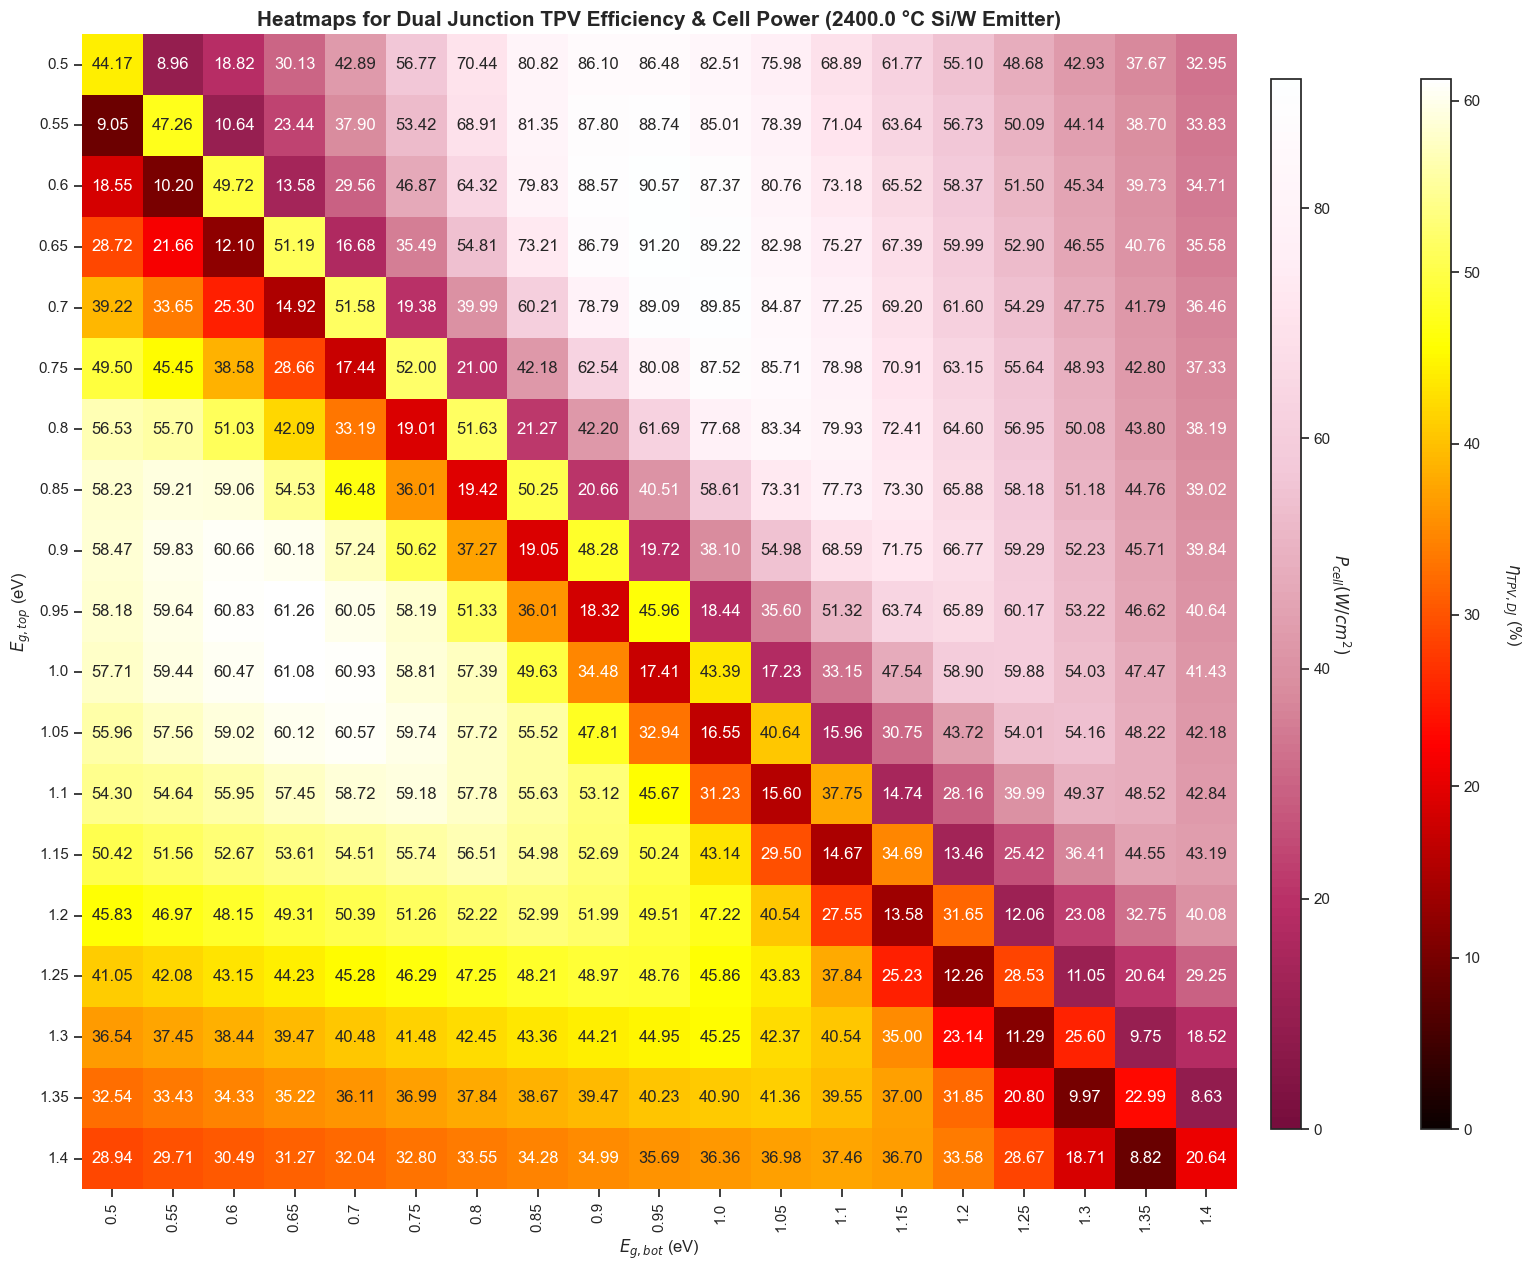

In [125]:
"""
Section 4: Creating the Heatmap 
"""

"""
heat_map() is the function that creates the heatmaps. 
see more @ https://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap



heatmap(data, *, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None, fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, cbar_kws=None, cbar_ax=None, 
        #square=False, xticklabels='auto', yticklabels='auto', mask=None, ax=None, **kwargs)

"""

import seaborn as sns 
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap

newcolors = plt.get_cmap('PiYG', 256)(np.linspace(0, .48, 256))

for i in range(0,len(newcolors)):
    newcolors[i,0] = min(.027+newcolors[i,0]**1.4,1)
    newcolors[i,1] = min(.046+newcolors[i,1]**.9,1)
    newcolors[i,2] = min(.057+newcolors[i,2]**1.5,1)
    
newcmp = ListedColormap(newcolors) #updated colormap with 'newcolors' and this is a specific colormap, not a string defining the name of the cmap, so don't put quotes 



#actual plotting 


sns.set_theme(style = 'ticks')            #by default it has its own ticks unless you specify what kind of background you want 
fig, ax = plt.subplots(figsize = (15,15)) #I only need one ax because both heatmaps are going on the same ax


"""
To create this specific heatmap, I needed to do the following

1) Take the transpose of the P_cell_grid, so that way all of the values get repositioned to the upper right triangle/upper right corner

2) I needed to mask all the empty squares in the P_cell_grid transpose and the efficiency_grid. 

3) Plot both of them on the same ax(i.e. same plot) 

to better understand the mask, read it inside out

mask = np.triu(np.ones_like(efficiency_grid, dtype = bool), k = 1)
    - np.ones_like(efficiency_grid, dtype = bool) --> creates an array of ones that has the same dimensions as efficiency grid, but the data-type of each entry is a boolean.
    - booleans are 1's and 0's.
    - 1's --> True, 0 --> false 
    - So np.ones_like(efficiency_grid, dtype = bool) ends up creating an array of 'True' values 
    np.triu(A , k = B) will zero out everything from the k = B row and onward of your A-array. So now the array is full of true-false values, and this mask gets fed to the function

mask = np.tril(np.ones_like(P_cell_grid.T, dtype = bool), k = 0)

this all gets plotted onto ax, fig is the canvas 

"""

#Testing to see if these match up 
o = 12                                  #o is the index of the emitter type, see above 
k = 7                                   #k is the index of the specific temperature in T_emitter that I want to call 

"""
indices for the emitters are as follows:

    - 0 --> AlN/W 
    - 1 --> Yb2O3/W
    - 2 --> MgO/W
    - 3 --> Y2O3/W 
    - 4 --> BeO/W    
    - 5 --> ZrO2/W  
    - 6 --> SiO2/W
    - 7 --> TiO2/W  
    - 8 --> SiN/W  
    - 9 --> SiC/W 
    - 10 --> a-C/W 
    - 11 --> TiN/W 
    - 12 --> Si/W
    
T_emitter = np.array([1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400])
"""
efficiency_grid = efficiency_ALLTEMP[o, k]
P_cell_grid = P_cell_ALLTEMP[o, k]
coating_grid = coating_ALLTEMP[o, k] 

#######################################

#sns.heatmap(coating_grid, vmin = 0, vmax = np.max(coating_grid), cmap = 'hot', xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = True, mask = np.triu(np.ones_like(coating_grid, dtype = bool), k = 1), fmt = '.2f', ax = ax, cbar = False, square = True)

sns.heatmap(efficiency_grid, vmin = 0, vmax = np.max(efficiency_grid), cmap = 'hot', xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = True, mask = np.triu(np.ones_like(efficiency_grid, dtype = bool), k = 1), fmt = '.2f', ax = ax, cbar = False, square = True)


sns.heatmap(P_cell_grid.T, vmin = 0, vmax = np.max(P_cell_grid.T), cmap = newcmp, xticklabels = np.round(Eg_Array,2), yticklabels = np.round(Eg_Array,2), annot = True, mask = np.tril(np.ones_like(P_cell_grid.T, dtype = bool), k = 0) , fmt = '.2f', ax = ax, cbar = False, square = True)
                    #plots the heatmap on its own ticks


# Colorbar for P_cell
sm_pcell = ScalarMappable(cmap = newcmp, norm=Normalize(vmin=0, vmax=np.max(P_cell_grid.T))) #basically defines the input of the colorbar. 
cbar_ax1 = fig.add_axes([0.92, 0.15, 0.02, 0.7])                                             #position of the colorbar [left, bottom, width, height] in figure coords
P_cell_CBAR = fig.colorbar(sm_pcell, cax=cbar_ax1)                                           #plotting the colorbar onto the figure using the input, sm_pcell, and the location, cbar_ax1 
P_cell_CBAR.set_label(r'$P_{cell} (W/cm^{2})$', rotation = 270, labelpad = 15)               #labeling the color bar 

# Colorbar for efficiency
#sm_eff = ScalarMappable(cmap='hot', norm=Normalize(vmin=0, vmax=np.max(coating_grid)))
sm_eff = ScalarMappable(cmap='hot', norm=Normalize(vmin=0, vmax=np.max(efficiency_grid)))
cbar_ax2 = fig.add_axes([1.02, 0.15, 0.02, 0.7])  
eta_CBAR = fig.colorbar(sm_eff, cax=cbar_ax2)
eta_CBAR.set_label(r'$\eta_{TPV, DJ}$ (%)', rotation = 270, labelpad = 30) 


ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.set_yticklabels(ax.get_yticklabels(), rotation = 0)

ax.set_ylabel(r'$E_{g, top}$ (eV)') 
ax.set_xlabel(r'$E_{g, bot}$ (eV)') 


ax.set_title(f'Heatmaps for Dual Junction TPV Efficiency & Cell Power ({np.round(T_emitter[k]-273.15,0)} °C {emitter_names[o]} Emitter)', fontsize = 15, fontweight = 'bold')



plt.show()



 

In [25]:
"""
Section 4.5: Correlating temperature with efficiency and cell power, and type of emitters
"""
import pandas as pd
import dataframe_image as dfi 

efficiency_max_vals = np.zeros(len(T_emitter)) #Each entry is the maximum efficiency across all emitters per temperature

idx_array_eta_global = np.zeros( (len(T_emitter), 4), dtype = int)

coating_layer_vals_global = np.zeros( len(T_emitter) ) 


max_power_vals = np.zeros(len(T_emitter))

idx_max_power_vals = np.zeros( (len(T_emitter), 4), dtype = int)

coating_layer_vals_power = np.zeros( len(T_emitter) ) 


efficiency_vs_temp = np.zeros( (num_emitters, len(T_emitter)) ) #for each emitter; each row will contain efficiency values at each temperature, with the rows representing emitter type 

coating_layer_vals = np.zeros( (num_emitters, len(T_emitter)) ) #Coating layer thicknesses vs. temperature, each row --> emitter type, and each row = a curve/set of points to plot 



for temp_index in range(0, len(T_emitter)):

    _slice = efficiency_ALLTEMP[:, temp_index, :, :]     #Defining the slice of the global efficiency array that you want to index and look into 
    
    efficiency_max_vals[temp_index] = np.max(_slice)
    
    flat_index = np.argmax(_slice)

    emitter_idx, EgTOP_idx, EgBOT_idx = np.unravel_index(flat_index, _slice.shape) #the argument of this function is (index you want to unravel, (the array you indexed it from).shape) 

    idx_array_eta_global[temp_index] = np.array([emitter_idx, temp_index, EgTOP_idx, EgBOT_idx]) 

    coating_layer_vals_global[temp_index] = coating_ALLTEMP[emitter_idx, temp_index, EgTOP_idx, EgBOT_idx]


    _slice_power = P_cell_ALLTEMP[:, temp_index, :, :]     #Defining the slice of the global efficiency array that you want to index and look into 
    
    max_power_vals[temp_index] = np.max(_slice_power)
    
    flat_index_power = np.argmax(_slice_power)

    emitter_idx_power, EgTOP_idx_power, EgBOT_idx_power = np.unravel_index(flat_index_power, _slice_power.shape) #the argument of this function is (index you want to unravel, (the array you indexed it from).shape) 

    idx_max_power_vals[temp_index] = np.array([emitter_idx_power, temp_index, EgTOP_idx_power, EgBOT_idx_power]) 

    coating_layer_vals_power[temp_index] = coating_ALLTEMP[emitter_idx_power, temp_index, EgTOP_idx_power, EgBOT_idx_power]


    

    
for emitter_type in range(0, num_emitters):

    efficiency_grid_ALLTEMP = efficiency_ALLTEMP[emitter_type, :, :, :] #selected an emitter, and are now viewing all 8 heatmpas 

    for temp_index, temp in enumerate(efficiency_grid_ALLTEMP):  #temp is the heatmap at that temperature 

        efficiency_vs_temp[emitter_type, temp_index] = np.max(temp) 

        flat_index = np.argmax(temp)         #finding the indices of EgTOP and EgBOT for that value of maximum efficiency, at this specific temperature 

        idx_EgTOP, idx_EgBOT = np.unravel_index(flat_index, temp.shape) 

        coating_layer_vals[emitter_type, temp_index] = coating_ALLTEMP[emitter_type, temp_index, idx_EgTOP, idx_EgBOT] #so this will be a row that later gets used to index into the coating grid 


#print(efficiency_max_vals) #global efficiency vs. temperature --> plot 
#print(coating_layer_vals_global) 
#print(idx_array_global)    #indices of the aforementioned values, will need to translate these into a table 
#print(idx_max_power_vals)  #indices of the global powers vs. 
#print(efficiency_vs_temp)  #local maximum efficiency vs. temperature --> multiple curves on a single plot 
#print(coating_layer_vals)  #coating layer thicknesses for each emitter vs. temperature --> will be a table to support aforementioned plot 


In [26]:
"""
Section 5.0: Creating the tables for the calculated values 
"""

#Creating the Tables


#Table 1 
df_optimizer_results = pd.DataFrame({
    r'T(°C)': T_emitter - 273.15, 
    r'efficiency (%)': efficiency_max_vals,
    r'$E_{g,top}$ (eV)': [Eg_Array[idx_array_eta_global[temp_index, 2]] for temp_index in range(0, len(T_emitter))],
    r'$E_{g,bot}$ (eV)': [Eg_Array[idx_array_eta_global[temp_index, 3]] for temp_index in range(0, len(T_emitter))],
    r'Emitter': [emitter_names[idx_array_eta_global[temp_index, 0]] for temp_index in range(0, len(T_emitter))],
    r'$d_{coating}$(nm)': coating_layer_vals_global 
     
})

display(df_optimizer_results)

dfi.export(df_optimizer_results, 'optimizer_results.png', table_conversion='matplotlib')

#Table 2 
df_optimizer_results_power = pd.DataFrame({
    r'T(°C)': T_emitter - 273.15,
    r'Power (W/$cm^{2}$)': max_power_vals,
    r'$E_{g,top}$ (eV)': [Eg_Array[idx_max_power_vals[temp_index, 2]] for temp_index in range(0, len(T_emitter))],
    r'$E_{g,bot}$ (eV)': [Eg_Array[idx_max_power_vals[temp_index, 3]] for temp_index in range(0, len(T_emitter))],
    r'Emitter': [emitter_names[idx_max_power_vals[temp_index, 0]] for temp_index in range(0, len(T_emitter))],
    r'$d_{coating}$(nm)': coating_layer_vals_power 
     
})

display(df_optimizer_results_power)

dfi.export(df_optimizer_results_power, 'optimizer_results_power.png', table_conversion='matplotlib')


#Table #3: Local Maxima vs. Temperature, thickness tracking 

df_local_thickness = pd.DataFrame({
    r'Emitter': emitter_names,
    r'1000°C': coating_layer_vals[:, 0], 
    r'1200°C': coating_layer_vals[:, 1], 
    r'1400°C': coating_layer_vals[:, 2], 
    r'1600°C': coating_layer_vals[:, 3], 
    r'1800°C': coating_layer_vals[:, 4], 
    r'2000°C': coating_layer_vals[:, 5], 
    r'2200°C': coating_layer_vals[:, 6], 
    r'2400°C': coating_layer_vals[:, 7], 
})

display(df_local_thickness)

dfi.export(df_local_thickness, 'local_thickness.png', table_conversion = 'matplotlib')

#Table 4: local efficiency vs temperature 

df_local_efficiency = pd.DataFrame({
    r'Emitter': emitter_names,
    r'1000°C': efficiency_vs_temp[:, 0], 
    r'1200°C': efficiency_vs_temp[:, 1], 
    r'1400°C': efficiency_vs_temp[:, 2], 
    r'1600°C': efficiency_vs_temp[:, 3], 
    r'1800°C': efficiency_vs_temp[:, 4], 
    r'2000°C': efficiency_vs_temp[:, 5], 
    r'2200°C': efficiency_vs_temp[:, 6], 
    r'2400°C': efficiency_vs_temp[:, 7], 
})

display(df_local_efficiency)

dfi.export(df_local_efficiency, 'df_local_efficiency.png', table_conversion = 'matplotlib')

#Table 5: Selected Bandgap Combos and their Optimal Emitters


top_bandgaps = np.array([1.40, 1.20, 1.00, 0.8, 1.40, 1.05, 0.60, 0.75, 0.85, 0.95, 1.00, 0.85])
bot_bandgaps = np.array([1.20, 1.00, 0.80, 0.6, 1.00, 0.60, 0.50, 0.65, 0.75, 0.80, 0.90, 0.70])

idx_top_bandgaps = np.zeros(len(top_bandgaps), dtype = int)
idx_bot_bandgaps = np.zeros(len(top_bandgaps), dtype = int)

for Eg_idx in range(0, len(top_bandgaps)):

    idx_TOP = np.argmin(np.abs(Eg_Array - top_bandgaps[Eg_idx]))
    idx_BOT = np.argmin(np.abs(Eg_Array - bot_bandgaps[Eg_idx]))

    idx_top_bandgaps[Eg_idx] = idx_TOP
    idx_bot_bandgaps[Eg_idx] = idx_BOT 


selected_emitter = [] 
selected_efficiency = np.zeros( len(top_bandgaps) )
selected_coating = np.zeros( len(top_bandgaps) ) 
selected_temperature = np.zeros( len(top_bandgaps) ) 



for Eg_idx in range(0, len(top_bandgaps)):
    
    _slice = efficiency_ALLTEMP[:, :, idx_top_bandgaps[Eg_idx], idx_bot_bandgaps[Eg_idx]] # "I want to optimize around this bandgap combination" 

    flat_idx = np.argmax(_slice) #flattened index containing the index of the chosen emitter, and chosen temperature

    idx_emitter, idx_temp = np.unravel_index(flat_idx, _slice.shape)

    selected_emitter.append(emitter_names[idx_emitter])

    selected_efficiency[Eg_idx] = np.max(_slice) 

    selected_temperature[Eg_idx] = T_emitter[idx_temp] 

    selected_coating[Eg_idx] = coating_ALLTEMP[idx_emitter, idx_temp, idx_top_bandgaps[Eg_idx], idx_bot_bandgaps[Eg_idx]]


df_selected_bandgaps = pd.DataFrame({
    r'$E_{g,top}$ (eV)': top_bandgaps,
    r'$E_{g,bot}$ (eV)': bot_bandgaps,
    r'efficiency (%)': selected_efficiency,
    r'T(°C)': selected_temperature - 273.15,
    r'Emitter': selected_emitter,
    r'$d_{coating}$(nm)': selected_coating   
})

display(df_selected_bandgaps)
dfi.export(df_selected_bandgaps, 'df_selected_bandgaps.png', table_conversion = 'matplotlib')

"""
for temp_index in range(0, len(T_emitter)):

idx_emitter = np.argmax(efficiency_ALLTEMP[:, temp_index, idx_top_bandgaps[Eg_idx], bot_bandgaps[Eg_idx]]) 

selected_emitter = emitter_names[idx_emitter] 
"""


,T(°C),efficiency (%),"$E_{g,top}$ (eV)","$E_{g,bot}$ (eV)",Emitter,$d_{coating}$(nm)
0,1000.0,44.867,0.70,0.50,Si/W,84.0
1,1200.0,49.889,0.75,0.50,Si/W,74.0
2,1400.0,53.233,0.80,0.55,Si/W,67.0
3,1600.0,55.646,0.85,0.60,Si/W,61.0
4,1800.0,57.526,0.85,0.60,Si/W,67.0
5,2000.0,58.838,0.90,0.60,Si/W,58.0
6,2200.0,59.976,0.95,0.65,Si/W,53.0
7,2400.0,60.781,0.95,0.65,Si/W,58.0


,T(°C),Power (W/$cm^{2}$),"$E_{g,top}$ (eV)","$E_{g,bot}$ (eV)",Emitter,$d_{coating}$(nm)
0,1000.0,1.232575,0.70,0.50,SiC/W,96.0
1,1200.0,3.279535,0.75,0.55,SiC/W,89.0
2,1400.0,7.318943,0.75,0.50,SiC/W,93.0
3,1600.0,14.318347,0.80,0.55,SiC/W,85.0
4,1800.0,25.346127,0.85,0.60,SiC/W,78.0
5,2000.0,41.250839,0.90,0.65,SiC/W,71.0
6,2200.0,63.653464,0.90,0.60,SiC/W,74.0
7,2400.0,94.119263,0.95,0.65,SiC/W,68.0


,Emitter,1000°C,1200°C,1400°C,1600°C,1800°C,2000°C,2200°C,2400°C
0,AlN/W,129.0,124.0,138.0,133.0,114.0,106.0,119.0,106.0
1,$Yb_{2}O_{3}$/W,149.0,130.0,133.0,149.0,134.0,125.0,110.0,126.0
2,MgO/W,167.0,147.0,152.0,172.0,154.0,143.0,125.0,122.0
3,$Y_{2}O_{3}$/W,149.0,130.0,133.0,148.0,134.0,125.0,110.0,125.0
4,BeO/W,169.0,148.0,153.0,174.0,156.0,145.0,127.0,123.0
5,$ZrO_{2}$/W,130.0,125.0,114.0,134.0,115.0,107.0,119.0,107.0
6,$SiO_{2}$/W,204.0,177.0,164.0,224.0,199.0,183.0,157.0,153.0
7,$TiO_{2}$/W,118.0,113.0,132.0,120.0,103.0,95.0,106.0,95.0
8,SiN/W,79.0,92.0,85.0,77.0,84.0,74.0,68.0,60.0
9,SiC/W,96.0,85.0,77.0,70.0,78.0,68.0,63.0,56.0


,Emitter,1000°C,1200°C,1400°C,1600°C,1800°C,2000°C,2200°C,2400°C
0,AlN/W,43.085,48.043,51.535,54.265,56.349,57.854,58.921,59.928
1,$Yb_{2}O_{3}$/W,42.231,47.292,50.897,53.673,55.826,57.377,58.525,59.489
2,MgO/W,41.595,46.821,50.406,53.178,55.397,56.989,58.218,59.162
3,$Y_{2}O_{3}$/W,42.305,47.357,50.962,53.719,55.878,57.425,58.577,59.525
4,BeO/W,41.568,46.797,50.379,53.146,55.368,56.961,58.194,59.135
5,$ZrO_{2}$/W,43.053,48.018,51.516,54.241,56.332,57.841,58.907,59.922
6,$SiO_{2}$/W,40.157,45.671,49.281,51.983,54.357,56.039,57.438,58.415
7,$TiO_{2}$/W,43.501,48.410,51.901,54.646,56.620,58.115,59.223,60.167
8,SiN/W,44.506,49.531,52.965,55.478,57.180,58.624,59.809,60.563
9,SiC/W,44.781,49.802,53.131,55.546,57.285,58.617,59.706,60.373


,"$E_{g,top}$ (eV)","$E_{g,bot}$ (eV)",efficiency (%),T(°C),Emitter,$d_{coating}$(nm)
0,1.40,1.20,35.002,2400.0,AlN/W,293.0
1,1.20,1.00,45.482,2400.0,$TiO_{2}$/W,326.0
2,1.00,0.80,54.714,2400.0,SiN/W,295.0
3,0.80,0.60,55.805,1800.0,Si/W,83.0
4,1.40,1.00,38.229,2400.0,AlN/W,258.0
5,1.05,0.60,58.775,2400.0,SiN/W,44.0
6,0.60,0.50,39.011,1000.0,Si/W,446.0
7,0.75,0.65,44.270,1400.0,Si/W,345.0
8,0.85,0.75,42.988,1600.0,Si/W,296.0
9,0.95,0.80,50.822,2200.0,Si/W,268.0


'\nfor temp_index in range(0, len(T_emitter)):\n\nidx_emitter = np.argmax(efficiency_ALLTEMP[:, temp_index, idx_top_bandgaps[Eg_idx], bot_bandgaps[Eg_idx]]) \n\nselected_emitter = emitter_names[idx_emitter] \n'

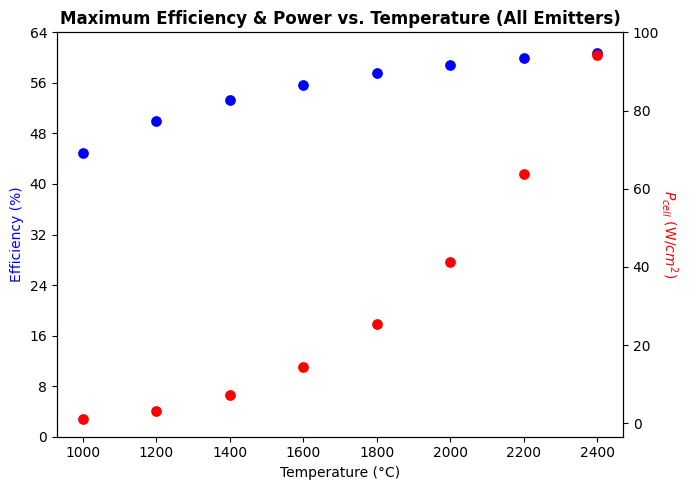

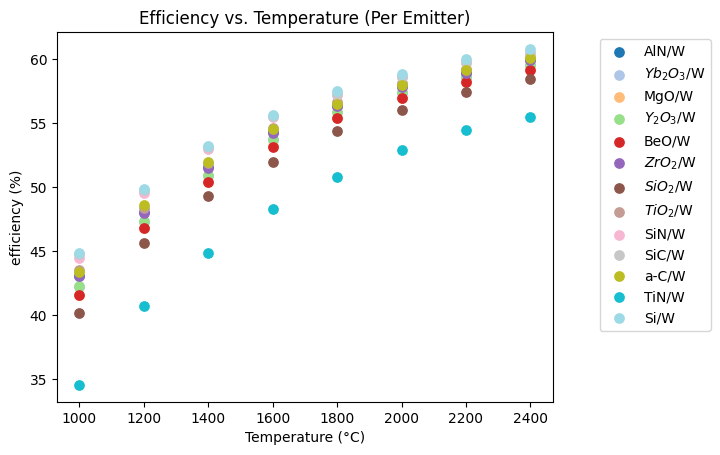

In [27]:
"""
Section 5.5: Creating the plots 
"""

#Global Power and Efficiency vs. Temperature 


fig, ax1 = plt.subplots(figsize = (7,5)) 

ax1.scatter(T_emitter - 273.15, efficiency_max_vals, color = 'blue', s = 45)
ax1.set_xlabel('Temperature (°C)') 
ax1.set_ylabel('Efficiency (%)', color = 'blue')
ax1.set_yticks(np.arange(0, np.round(np.max(efficiency_max_vals)) + 10, 8))

ax2 = ax1.twinx()

ax2.scatter(T_emitter - 273.15, max_power_vals, color = 'red', s = 45)
ax2.set_ylabel(r'$P_{cell}$ (W/$cm^{2}$)', color = 'red', rotation = -90, labelpad = 15)
ax2.set_yticks(np.arange(0, np.round(np.max(max_power_vals)) + 20, 20))

plt.title('Maximum Efficiency & Power vs. Temperature (All Emitters)', fontweight = 'bold') 
fig.tight_layout()

plt.show()


#Plot #2: local efficiency vs. temperature 
#cmap = cm.get_cmap('gist_rainbow')

colors = plt.cm.tab20(np.linspace(0, 1, 13))

for emitter_type in range(0, num_emitters):
    color =  colors[emitter_type]
    #color = cmap(0.85 - 0.8 * emitter_type/(num_emitters -1))
    plt.scatter(T_emitter - 273.15, efficiency_vs_temp[emitter_type], color = color, label = emitter_names[emitter_type], s = 45)
    #plt.plot(T_emitter - 273.15, efficiency_vs_temp[emitter_type], color = color, label = emitter_names[emitter_type])
    
plt.xlabel('Temperature (°C)')
plt.ylabel('efficiency (%)')
plt.legend(bbox_to_anchor = (1.08, 1), loc = 'upper left')
plt.title('Efficiency vs. Temperature (Per Emitter)')
plt.show()